In [1]:
!pip install --upgrade scikit-learn==1.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 31.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
# ============================================
# STEP 1: Mount Google Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================
# STEP 2: Import Required Libraries
# ============================================

# For data handling
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# For saving models
import joblib
import os

# Ignore harmless warnings for a cleaner notebook
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# ============================================
# STEP 3: Load Dataset from Google Drive
# ============================================

file_path = '/content/drive/MyDrive/Machine Learning Projects/Heart_Disease_ML_Project.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (918, 12)


In [5]:
# ============================================
# STEP 4: Initial Dataset Inspection
# ============================================

# 1. Shape
print("Dataset Shape:", df.shape)

# 2. First 5 rows
print("\nFirst 5 Rows:")
df.head()
# 3. Dataset info
print("Dataset Info:")
df.info()
# 4. Missing values per column
print("Missing Values per Column:")
df.isnull().sum().sort_values(ascending=False)

Dataset Shape: (918, 12)

First 5 Rows:
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
Missing Values per Column:


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


HeartDisease Value Counts:
HeartDisease
1    508
0    410
Name: count, dtype: int64

HeartDisease Class Percentage:
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


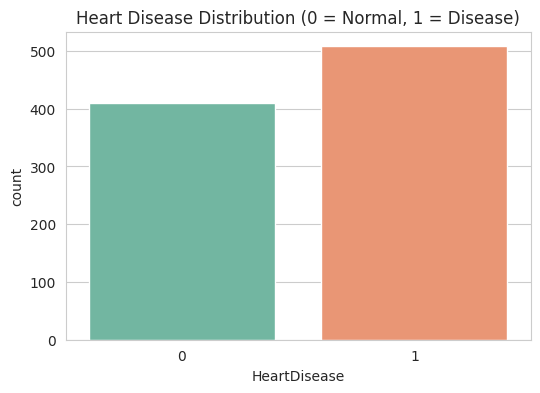

In [6]:
# ============================================
# STEP 5.1: Target Class Distribution
# ============================================
print("HeartDisease Value Counts:")
print(df['HeartDisease'].value_counts())
print("\nHeartDisease Class Percentage:")
print(df['HeartDisease'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=df, palette='Set2')
plt.title('Heart Disease Distribution (0 = Normal, 1 = Disease)')
plt.show()

In [7]:
# ============================================
# STEP 5.2: Check for Disguised Missing Values (0s that shouldn't be 0)
# ============================================
print("Rows with Cholesterol = 0:", (df['Cholesterol'] == 0).sum())
print("Rows with RestingBP = 0:", (df['RestingBP'] == 0).sum())

print("\nCholesterol distribution:")
print(df['Cholesterol'].describe())

Rows with Cholesterol = 0: 172
Rows with RestingBP = 0: 1

Cholesterol distribution:
count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64


In [8]:
# ============================================
# STEP 5.3: Correlation Heatmap (Numeric Features)
# ============================================
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size': 7})
plt.title('Correlation Heatmap - Heart Disease Dataset')
plt.tight_layout()
plt.savefig('heart_correlation_heatmap.png', dpi=150)
plt.show()

ValueError: could not convert string to float: 'M'

<Figure size 1200x1000 with 0 Axes>

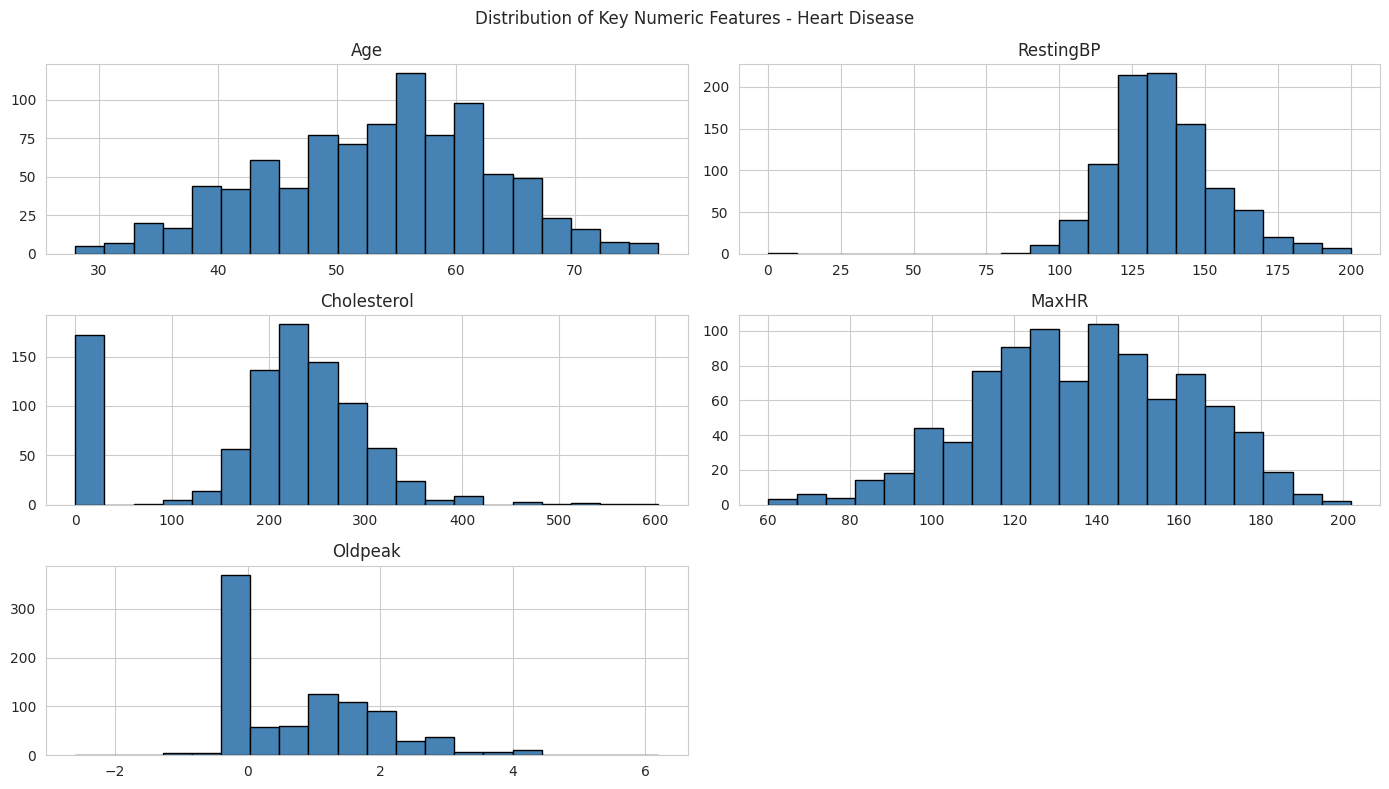

              Age   RestingBP  Cholesterol       MaxHR     Oldpeak
count  918.000000  918.000000   918.000000  918.000000  918.000000
mean    53.510893  132.396514   198.799564  136.809368    0.887364
std      9.432617   18.514154   109.384145   25.460334    1.066570
min     28.000000    0.000000     0.000000   60.000000   -2.600000
25%     47.000000  120.000000   173.250000  120.000000    0.000000
50%     54.000000  130.000000   223.000000  138.000000    0.600000
75%     60.000000  140.000000   267.000000  156.000000    1.500000
max     77.000000  200.000000   603.000000  202.000000    6.200000


In [9]:
# ============================================
# STEP 5.4: Histograms of Numeric Features
# ============================================
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

df[numeric_features].hist(figsize=(14, 8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Key Numeric Features - Heart Disease')
plt.tight_layout()
plt.savefig('heart_histograms.png', dpi=150)
plt.show()

print(df[numeric_features].describe())

In [10]:
# ============================================
# STEP 5.5: Outlier Detection (IQR method)
# ============================================
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower_bound:.2f} to {upper_bound:.2f})")

Age: 0 outliers (bounds: 27.50 to 79.50)
RestingBP: 28 outliers (bounds: 90.00 to 170.00)
Cholesterol: 183 outliers (bounds: 32.62 to 407.62)
MaxHR: 2 outliers (bounds: 66.00 to 210.00)
Oldpeak: 16 outliers (bounds: -2.25 to 3.75)


In [11]:
# ============================================
# STEP 6.1: Convert Disguised Missing Values (0) to NaN, then Impute
# ============================================
# Cholesterol=0 and RestingBP=0 are physiologically impossible —
# they represent missing data recorded as 0, not real measurements.

df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

print("Missing values after converting disguised zeros:")
print(df[['Cholesterol', 'RestingBP']].isnull().sum())

# Impute with median (robust to skew, same approach as before)
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())
df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())

print("\nMissing values after imputation:")
print(df[['Cholesterol', 'RestingBP']].isnull().sum())
print(f"\nNew Cholesterol distribution:\n{df['Cholesterol'].describe()}")

Missing values after converting disguised zeros:
Cholesterol    172
RestingBP        1
dtype: int64

Missing values after imputation:
Cholesterol    0
RestingBP      0
dtype: int64

New Cholesterol distribution:
count    918.000000
mean     243.204793
std       53.401297
min       85.000000
25%      214.000000
50%      237.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64


In [12]:
# ============================================
# STEP 6.2: Check for Duplicate Rows
# ============================================
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [13]:
# ============================================
# STEP 7: Feature Engineering Check
# ============================================
# All 11 features are legitimate clinical inputs — no leakage, no IDs to drop.
# Confirming categorical columns and their unique values before encoding.

categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Sex: ['M' 'F']
ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
RestingECG: ['Normal' 'ST' 'LVH']
ExerciseAngina: ['N' 'Y']
ST_Slope: ['Up' 'Flat' 'Down']


In [14]:
# ============================================
# STEP 8: Encode Categorical Variables
# ============================================
# Sex, ExerciseAngina: 2 categories each -> Label Encoding (binary, no order issue)
# ChestPainType, RestingECG, ST_Slope: 3-4 categories, no natural order -> One-Hot Encoding

le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])

le_angina = LabelEncoder()
df['ExerciseAngina'] = le_angina.fit_transform(df['ExerciseAngina'])

df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], prefix=['CP', 'ECG', 'Slope'])

print(f"Shape after encoding: {df.shape}")
print(df.columns.tolist())

Shape after encoding: (918, 19)
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'CP_ASY', 'CP_ATA', 'CP_NAP', 'CP_TA', 'ECG_LVH', 'ECG_Normal', 'ECG_ST', 'Slope_Down', 'Slope_Flat', 'Slope_Up']


In [15]:
# ============================================
# STEP 9: Correlation with Target
# ============================================
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

corr_with_target = X.corrwith(y).sort_values(ascending=False)
print("Correlation with HeartDisease:")
print(corr_with_target)

Correlation with HeartDisease:
Slope_Flat        0.554134
CP_ASY            0.516716
ExerciseAngina    0.494282
Oldpeak           0.403951
Sex               0.305445
Age               0.282039
FastingBS         0.267291
Slope_Down        0.122527
RestingBP         0.117798
ECG_ST            0.102527
Cholesterol       0.076114
ECG_LVH           0.010670
CP_TA            -0.054790
ECG_Normal       -0.091580
CP_NAP           -0.212964
MaxHR            -0.400421
CP_ATA           -0.401924
Slope_Up         -0.622164
dtype: float64


In [16]:
# ============================================
# STEP 10-11: Train-Test Split (Stratified) + Scaling
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")
print(f"\nTrain label ratio:\n{y_train.value_counts(normalize=True)*100}")
print(f"\nTest label ratio:\n{y_test.value_counts(normalize=True)*100}")

X_train: (734, 18), X_test: (184, 18)

Train label ratio:
HeartDisease
1    55.313351
0    44.686649
Name: proportion, dtype: float64

Test label ratio:
HeartDisease
1    55.434783
0    44.565217
Name: proportion, dtype: float64


In [17]:
# ============================================
# STEP 12: Initialize All 8 Models
# ============================================
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

# ============================================
# STEP 13: Train and Evaluate Baseline Models
# ============================================
baseline_results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    baseline_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    print(f"{name} done.")

baseline_df = pd.DataFrame(baseline_results).sort_values(by='F1-Score', ascending=False)
print("\n=== Baseline Results (Before Tuning) ===")
baseline_df

Logistic Regression done.
KNN done.
Naive Bayes done.
Decision Tree done.
Random Forest done.
SVM done.
Gradient Boosting done.
AdaBoost done.

=== Baseline Results (Before Tuning) ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,Random Forest,0.891304,0.894231,0.911765,0.902913,0.930835
5,SVM,0.885870,0.909091,0.882353,0.895522,0.937470
7,AdaBoost,0.885870,0.909091,0.882353,0.895522,0.922047
6,Gradient Boosting,0.880435,0.892157,0.892157,0.892157,0.918580
0,Logistic Regression,0.875000,0.898990,0.872549,0.885572,0.931612
1,KNN,0.869565,0.882353,0.882353,0.882353,0.925634
2,Naive Bayes,0.858696,0.880000,0.862745,0.871287,0.899928
3,Decision Tree,0.793478,0.820000,0.803922,0.811881,0.792205


In [18]:
# ============================================
# STEP 14.0: Define Hyperparameter Grids
# ============================================
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    }
}

print("Hyperparameter grids defined.")

Hyperparameter grids defined.


In [19]:
# ============================================
# STEP 14: Hyperparameter Tuning with GridSearchCV
# ============================================
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_models = {}
tuned_results = []

for name, model in models.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring='f1',
        cv=cv_strategy,
        n_jobs=-1
    )
    grid_search.fit(X_train_scaled, y_train)

    best_model = grid_search.best_estimator_
    tuned_models[name] = best_model

    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

    tuned_results.append({
        'Model': name,
        'Best Params': grid_search.best_params_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    print(f"  Done. Best F1 (CV): {grid_search.best_score_:.4f}")

tuned_df = pd.DataFrame(tuned_results).sort_values(by='F1-Score', ascending=False)
print("\n=== Tuned Results (After Tuning) ===")
tuned_df

Tuning Logistic Regression...
  Done. Best F1 (CV): 0.8577
Tuning KNN...
  Done. Best F1 (CV): 0.8647
Tuning Naive Bayes...
  Done. Best F1 (CV): 0.8444
Tuning Decision Tree...
  Done. Best F1 (CV): 0.8456
Tuning Random Forest...
  Done. Best F1 (CV): 0.8791
Tuning SVM...
  Done. Best F1 (CV): 0.8728
Tuning Gradient Boosting...
  Done. Best F1 (CV): 0.8746
Tuning AdaBoost...
  Done. Best F1 (CV): 0.8784

=== Tuned Results (After Tuning) ===


,Model,Best Params,Accuracy,Precision,Recall,F1-Score,ROC-AUC
7,AdaBoost,"{'learning_rate': 0.1, 'n_estimators': 200}",0.891304,0.901961,0.901961,0.901961,0.927009
5,SVM,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.885870,0.909091,0.882353,0.895522,0.937470
0,Logistic Regression,"{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.885870,0.917526,0.872549,0.894472,0.931253
6,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.880435,0.892157,0.892157,0.892157,0.918580
1,KNN,"{'n_neighbors': 11, 'weights': 'uniform'}",0.875000,0.898990,0.872549,0.885572,0.931552
2,Naive Bayes,{'var_smoothing': 1e-09},0.858696,0.880000,0.862745,0.871287,0.899928
4,Random Forest,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",0.853261,0.871287,0.862745,0.866995,0.925873
3,Decision Tree,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",0.831522,0.873684,0.813725,0.842640,0.898673


In [20]:
# ============================================
# STEP 15: Before vs After Tuning Comparison
# ============================================
comparison_df = baseline_df[['Model', 'Accuracy', 'F1-Score']].merge(
    tuned_df[['Model', 'Accuracy', 'F1-Score']],
    on='Model', suffixes=(' (Before)', ' (After)')
)
comparison_df['F1 Change'] = comparison_df['F1-Score (After)'] - comparison_df['F1-Score (Before)']
comparison_df['Tuning Helped?'] = comparison_df['F1 Change'].apply(
    lambda x: 'Yes' if x > 0 else ('No Change' if x == 0 else 'No - Worse!')
)
comparison_df = comparison_df.sort_values(by='F1-Score (After)', ascending=False)
print(comparison_df)

                 Model  Accuracy (Before)  F1-Score (Before)  \
2             AdaBoost           0.885870           0.895522   
1                  SVM           0.885870           0.895522   
4  Logistic Regression           0.875000           0.885572   
3    Gradient Boosting           0.880435           0.892157   
5                  KNN           0.869565           0.882353   
6          Naive Bayes           0.858696           0.871287   
0        Random Forest           0.891304           0.902913   
7        Decision Tree           0.793478           0.811881   

   Accuracy (After)  F1-Score (After)  F1 Change Tuning Helped?  
2          0.891304          0.901961   0.006438            Yes  
1          0.885870          0.895522   0.000000      No Change  
4          0.885870          0.894472   0.008900            Yes  
3          0.880435          0.892157   0.000000      No Change  
5          0.875000          0.885572   0.003219            Yes  
6          0.858696        

In [21]:
# ============================================
# STEP 16: Finalize Model Set
# ============================================
# Random Forest's tuned version underperformed baseline (0.903 -> 0.889),
# so we revert to the baseline version. Everyone else uses their tuned version.

final_models = tuned_models.copy()

final_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
final_rf.fit(X_train_scaled, y_train)
final_models['Random Forest'] = final_rf

# Build final results table reflecting the corrected Random Forest
final_results = []
for name, model in final_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    final_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
final_df = pd.DataFrame(final_results).sort_values(by='F1-Score', ascending=False)
print("=== FINAL Model Results (baseline RF + tuned others) ===")
print(final_df)

=== FINAL Model Results (baseline RF + tuned others) ===
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
4        Random Forest  0.891304   0.894231  0.911765  0.902913  0.930835
7             AdaBoost  0.891304   0.901961  0.901961  0.901961  0.927009
5                  SVM  0.885870   0.909091  0.882353  0.895522  0.937470
0  Logistic Regression  0.885870   0.917526  0.872549  0.894472  0.931253
6    Gradient Boosting  0.880435   0.892157  0.892157  0.892157  0.918580
1                  KNN  0.875000   0.898990  0.872549  0.885572  0.931552
2          Naive Bayes  0.858696   0.880000  0.862745  0.871287  0.899928
3        Decision Tree  0.831522   0.873684  0.813725  0.842640  0.898673


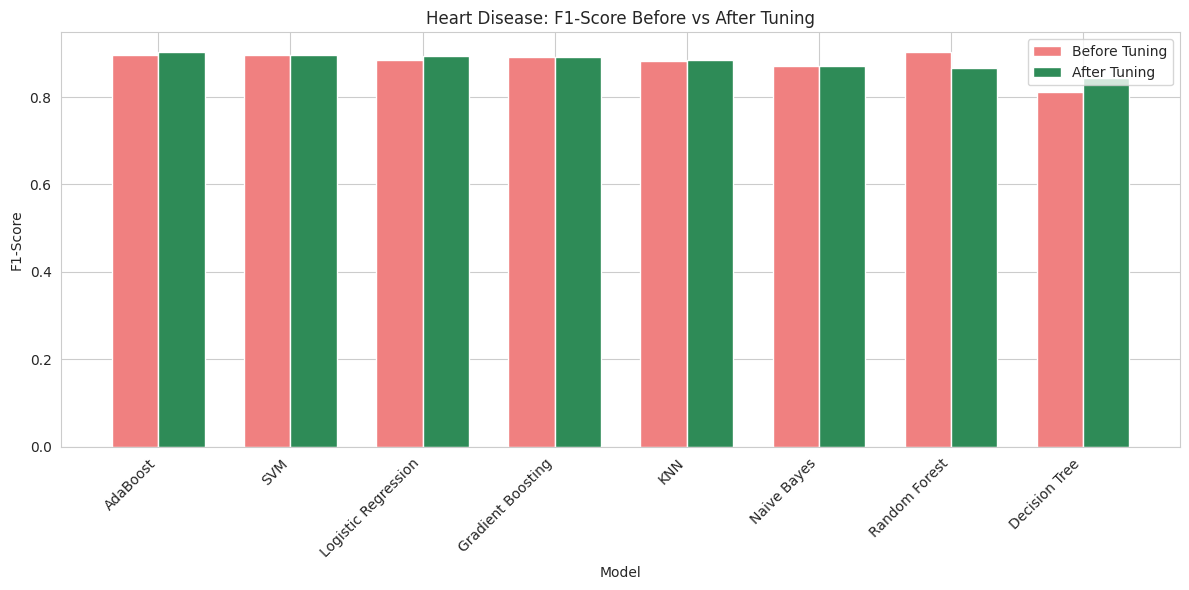

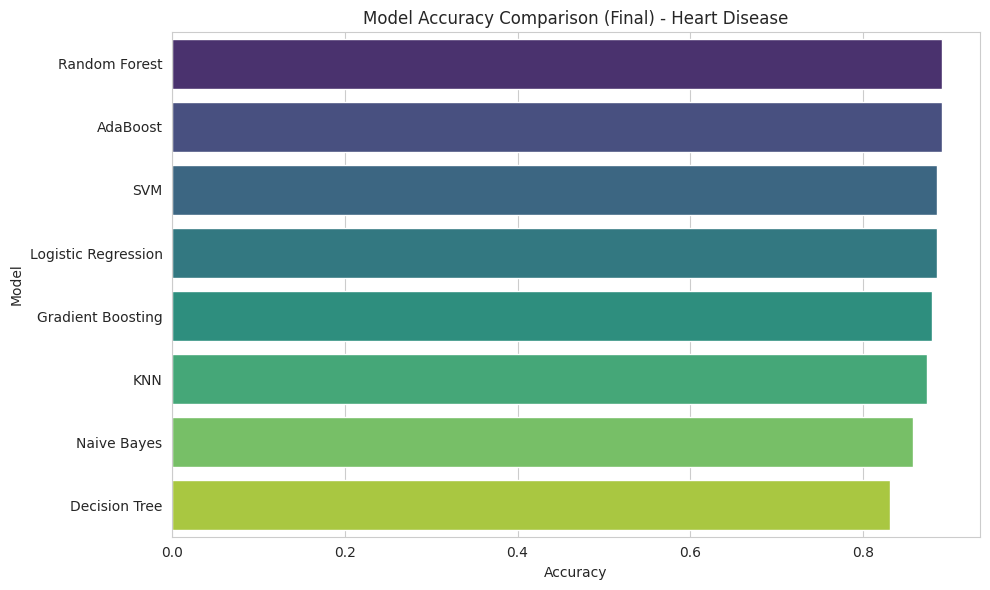

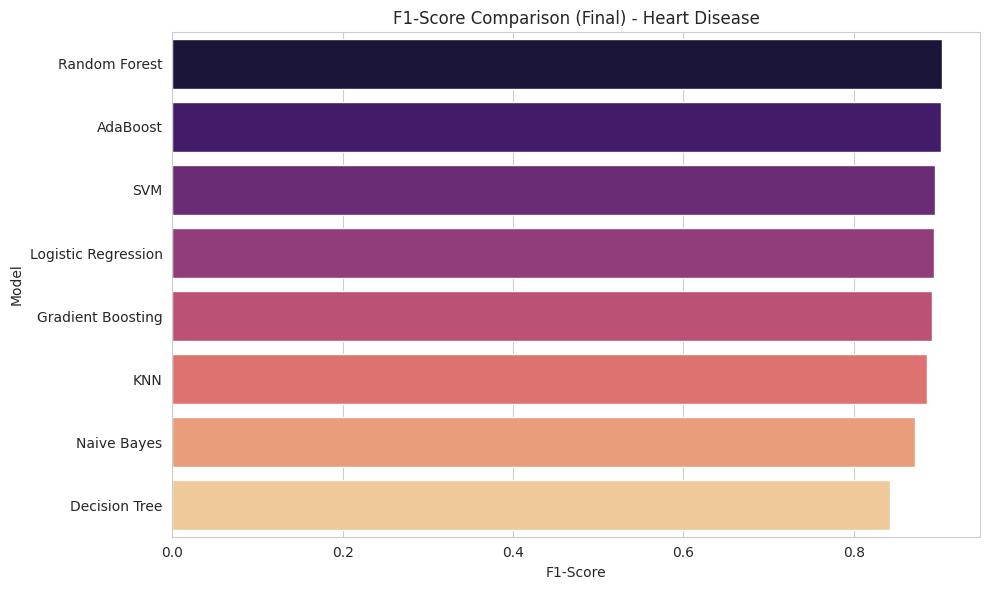

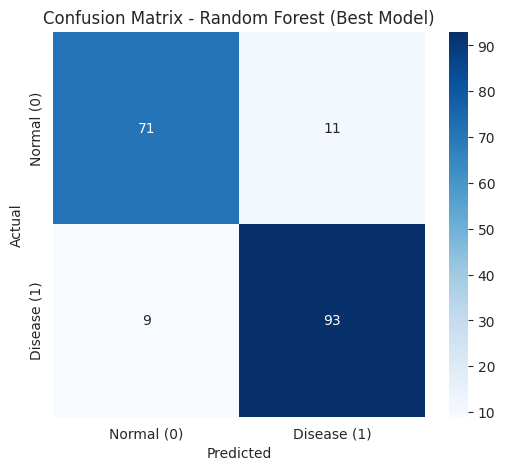

[[71 11]
 [ 9 93]]


In [22]:
# ============================================
# STEP 17.1: Before vs After Tuning Visualization
# ============================================
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df)); width = 0.35
plt.bar(x - width/2, comparison_df['F1-Score (Before)'], width, label='Before Tuning', color='lightcoral')
plt.bar(x + width/2, comparison_df['F1-Score (After)'], width, label='After Tuning', color='seagreen')
plt.xlabel('Model'); plt.ylabel('F1-Score')
plt.title('Heart Disease: F1-Score Before vs After Tuning')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend(); plt.tight_layout()
plt.savefig('heart_before_after_tuning_f1.png', dpi=150)
plt.show()

# ============================================
# STEP 17.2: Model Accuracy Comparison (Final Models)
# ============================================
plt.figure(figsize=(10, 6))
sorted_acc = final_df.sort_values(by='Accuracy', ascending=False)
sns.barplot(x='Accuracy', y='Model', data=sorted_acc, palette='viridis')
plt.title('Model Accuracy Comparison (Final) - Heart Disease')
plt.tight_layout()
plt.savefig('heart_accuracy_comparison.png', dpi=150)
plt.show()

# ============================================
# STEP 17.3: F1-Score Comparison (Final Models)
# ============================================
plt.figure(figsize=(10, 6))
sorted_f1 = final_df.sort_values(by='F1-Score', ascending=False)
sns.barplot(x='F1-Score', y='Model', data=sorted_f1, palette='magma')
plt.title('F1-Score Comparison (Final) - Heart Disease')
plt.tight_layout()
plt.savefig('heart_f1_comparison.png', dpi=150)
plt.show()

# ============================================
# STEP 17.4: Confusion Matrix - Best Model (Random Forest, baseline)
# ============================================
best_model = final_models['Random Forest']
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Disease (1)'],
            yticklabels=['Normal (0)', 'Disease (1)'])
plt.title('Confusion Matrix - Random Forest (Best Model)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.savefig('heart_confusion_matrix.png', dpi=150)
plt.show()
print(cm)

In [23]:
# ============================================
# STEP 18: Save All Models, Scaler, Encoders, Feature Info
# ============================================
local_dir = 'saved_models/notebook3'
drive_dir = '/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook3'
os.makedirs(local_dir, exist_ok=True)
os.makedirs(drive_dir, exist_ok=True)

for name, model in final_models.items():
    filename = 'heart_' + name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(model, os.path.join(local_dir, filename))
    joblib.dump(model, os.path.join(drive_dir, filename))
    print(f"Saved: {filename}")

joblib.dump(scaler, os.path.join(local_dir, 'heart_scaler.pkl'))
joblib.dump(scaler, os.path.join(drive_dir, 'heart_scaler.pkl'))
joblib.dump(le_sex, os.path.join(local_dir, 'heart_sex_encoder.pkl'))
joblib.dump(le_sex, os.path.join(drive_dir, 'heart_sex_encoder.pkl'))
joblib.dump(le_angina, os.path.join(local_dir, 'heart_angina_encoder.pkl'))
joblib.dump(le_angina, os.path.join(drive_dir, 'heart_angina_encoder.pkl'))

feature_info = pd.DataFrame({'min': X.min(), 'max': X.max(), 'mean': X.mean(), 'dtype': X.dtypes})
feature_info.to_csv(os.path.join(local_dir, 'heart_feature_info.csv'))
feature_info.to_csv(os.path.join(drive_dir, 'heart_feature_info.csv'))

print("\nAll models, scaler, encoders, feature info saved (local + Drive).")

Saved: heart_logistic_regression.pkl
Saved: heart_knn.pkl
Saved: heart_naive_bayes.pkl
Saved: heart_decision_tree.pkl
Saved: heart_random_forest.pkl
Saved: heart_svm.pkl
Saved: heart_gradient_boosting.pkl
Saved: heart_adaboost.pkl

All models, scaler, encoders, feature info saved (local + Drive).


In [24]:
# ============================================
# DOCUMENTATION: Individual Confusion Matrix, ROC, and PR curves per model
# ============================================
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
import os

os.makedirs('doc_images', exist_ok=True)

def save_individual_cms(model_dict, stage, prefix):
    for name, model in model_dict.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        y_pred = model.predict(X_test_scaled)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot(ax=ax, cmap='Blues', colorbar=True)
        ax.set_title(f"Confusion Matrix \u2013 {name} ({stage})", fontsize=11)
        plt.tight_layout()
        safe_name = name.lower().replace(' ', '_')
        plt.savefig(f'doc_images/{prefix}_cm_{stage}_{safe_name}.png', dpi=150)
        plt.close(fig)

def save_individual_rocs(model_dict, stage, prefix):
    for name, model in model_dict.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
        ax.set_title(f"ROC Curve \u2013 {name} ({stage})", fontsize=11)
        plt.tight_layout()
        safe_name = name.lower().replace(' ', '_')
        plt.savefig(f'doc_images/{prefix}_roc_{stage}_{safe_name}.png', dpi=150)
        plt.close(fig)

def save_individual_prs(model_dict, stage, prefix):
    for name, model in model_dict.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        PrecisionRecallDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
        ax.set_title(f"Precision-Recall Curve \u2013 {name} ({stage})", fontsize=11)
        plt.tight_layout()
        safe_name = name.lower().replace(' ', '_')
        plt.savefig(f'doc_images/{prefix}_pr_{stage}_{safe_name}.png', dpi=150)
        plt.close(fig)

PREFIX = "heart"

# Baseline (8 models x 3 chart types = 24 images)
save_individual_cms(models, "baseline", PREFIX)
save_individual_rocs(models, "baseline", PREFIX)
save_individual_prs(models, "baseline", PREFIX)

# Final models (8 models x 3 chart types = 24 images)
# Note: Heart Disease used "final_models" (Random Forest reverted to baseline)
save_individual_cms(final_models, "tuned", PREFIX)
save_individual_rocs(final_models, "tuned", PREFIX)
save_individual_prs(final_models, "tuned", PREFIX)

print(f"Done. Total images saved: {len(os.listdir('doc_images'))}")

Done. Total images saved: 48


In [25]:
import shutil
from google.colab import files

shutil.make_archive('heart_doc_images_48', 'zip', 'doc_images')
files.download('heart_doc_images_48.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>